# Data Science Project 1 — Advanced EDA & Feature Engineering

---
**Objective:** Transform raw, chaotic data into a mathematically clean dataset ready for machine learning algorithms.

**Datasets:**
- `Online-Store-Orders.xlsx` → Online retail orders (order-level data)
- `Product-Sales-Region.xlsx` → Regional product sales (store-level data)

**Pipeline (IPO Architecture):**
1. **MODULE 1 — INPUT:** Securing Fidelity (Missing values + Outlier boundaries)
2. **MODULE 2 — PROCESS:** Vectorized math, Encoding, Collinearity eradication
3. **MODULE 3 — OUTPUT:** Validated contracts & Feature store

---

## 0. Environment Setup

In [1]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# ── Imputation ───────────────────────────────────────────────────────────────
from sklearn.impute import KNNImputer

# ── Data Validation (Pandera) ────────────────────────────────────────────────
try:
    import pandera as pa
    from pandera import Column, DataFrameSchema, Check
    PANDERA_AVAILABLE = True
except ImportError:
    PANDERA_AVAILABLE = False
    print("  Pandera not installed. Run: pip install pandera")

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid', palette='muted')

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR    = Path('..') 
DATA_RAW    = BASE_DIR / 'data' / 'raw'
DATA_PROC   = BASE_DIR / 'data' / 'processed'
PLOTS_DIR   = BASE_DIR / 'outputs' / 'plots'
REPORTS_DIR = BASE_DIR / 'outputs' / 'reports'

for p in [DATA_PROC, PLOTS_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'   NumPy   : {np.__version__}')
print(f'   Pandas  : {pd.__version__}')
print(f'   Pandera : {"available" if PANDERA_AVAILABLE else "not installed"}')

Environment ready.
   NumPy   : 2.1.3
   Pandas  : 2.2.3
   Pandera : available


---
## MODULE 1 — INPUT: Securing Fidelity
### 1.1 Load Datasets

In [2]:
orders = pd.read_excel(DATA_RAW / 'Online-Store-Orders.xlsx')
sales  = pd.read_excel(DATA_RAW / 'Product-Sales-Region.xlsx')

print(f' Online Store Orders : {orders.shape[0]:,} rows × {orders.shape[1]} columns')
print(f' Product Sales Region: {sales.shape[0]:,} rows × {sales.shape[1]} columns')

 Online Store Orders : 1,200 rows × 14 columns
 Product Sales Region: 1,500 rows × 19 columns


In [3]:
# ── Quick peek ───────────────────────────────────────────────────────────────
print('=== Online Store Orders — first 5 rows ===')
display(orders.head())

print('\n=== Product Sales Region — first 5 rows ===')
display(sales.head())

=== Online Store Orders — first 5 rows ===


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.6200,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.1000
1,ORD200001,2024-08-23,C75739,Phone,2,151.3500,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.7000
2,ORD200002,2024-02-27,C81728,Tablet,5,550.6800,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.4000
3,ORD200003,2023-10-15,C33540,Chair,1,273.1900,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.1900
4,ORD200004,2025-05-08,C81840,Printer,4,626.0100,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.0400



=== Product Sales Region — first 5 rows ===


,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,PaymentMethod,Promotion,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager
0,2023-02-23,East,Laptop,14,163.6000,Store B,Wholesale,0.0000,Eva,2290.4000,Online,FREESHIP,0,REG100000,Cust 6583,43.3400,2023-02-23,2023-02-27,Eric
1,2024-12-19,South,Phone,1,544.0100,Store A,Retail,0.0000,Alice,544.0100,Gift Card,SAVE10,0,REG100001,Cust 2144,5.3000,2024-12-19,2024-12-28,Sophie
2,2023-05-10,North,Desk,14,346.1800,Store B,Wholesale,0.1000,Alice,4361.8680,Online,WINTER15,0,REG100002,Cust 5998,20.4600,2023-05-10,2023-05-19,Ryan
3,2025-02-26,Central,Chair,18,384.8200,Store A,Wholesale,0.1500,Frank,5887.7460,Gift Card,FREESHIP,0,REG100003,Cust 7136,27.9500,2025-02-26,2025-03-02,Cameron
4,2023-06-24,East,Desk,18,237.7600,Store C,Retail,0.0000,Carlos,4279.6800,Online,SAVE10,0,REG100004,Cust 6506,5.7300,2023-06-24,2023-06-27,Eric


### 1.2 Schema & Data Types Inspection

In [4]:
def schema_report(df, name):
    """Quick schema summary: dtype, nulls, unique values."""
    report = pd.DataFrame({
        'dtype'       : df.dtypes,
        'non_null'    : df.notna().sum(),
        'null_count'  : df.isna().sum(),
        'null_pct'    : (df.isna().mean() * 100).round(2),
        'unique'      : df.nunique(),
        'sample_val'  : df.iloc[0]
    })
    print(f'\n=== Schema Report: {name} ===')
    display(report)
    return report

schema_orders = schema_report(orders, 'Online-Store-Orders')
schema_sales  = schema_report(sales,  'Product-Sales-Region')


=== Schema Report: Online-Store-Orders ===


,dtype,non_null,null_count,null_pct,unique,sample_val
OrderID,object,1200,0,0.0000,1200,ORD200000
Date,datetime64[ns],1200,0,0.0000,671,2023-01-04 00:00:00
CustomerID,object,1200,0,0.0000,1189,C72649
Product,object,1200,0,0.0000,7,Monitor
Quantity,int64,1200,0,0.0000,5,5
UnitPrice,float64,1200,0,0.0000,1193,570.6200
ShippingAddress,object,1200,0,0.0000,655,928 Main St
PaymentMethod,object,1200,0,0.0000,5,Debit Card
OrderStatus,object,1200,0,0.0000,5,Shipped
TrackingNumber,object,1200,0,0.0000,1200,TRK37947903



=== Schema Report: Product-Sales-Region ===


,dtype,non_null,null_count,null_pct,unique,sample_val
Date,datetime64[ns],1500,0,0.0000,747,2023-02-23 00:00:00
Region,object,1500,0,0.0000,5,East
Product,object,1500,0,0.0000,7,Laptop
Quantity,int64,1500,0,0.0000,20,14
UnitPrice,float64,1500,0,0.0000,1482,163.6000
StoreLocation,object,1500,0,0.0000,4,Store B
CustomerType,object,1500,0,0.0000,2,Wholesale
Discount,float64,1500,0,0.0000,4,0.0000
Salesperson,object,1500,0,0.0000,6,Eva
TotalPrice,float64,1500,0,0.0000,1500,2290.4000


### 1.3 Date Columns — Fix Excel Serial Numbers

In [5]:
def fix_excel_dates(df, cols):
    """Convert Excel serial-number dates to proper datetime."""
    for col in cols:
        if col in df.columns:
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col] = pd.to_datetime(df[col], unit='D', origin='1899-12-30', errors='coerce')
            else:
                df[col] = pd.to_datetime(df[col], errors='coerce')
    return df

orders = fix_excel_dates(orders, ['Date'])
sales  = fix_excel_dates(sales, ['Date', 'OrderDate', 'DeliveryDate'])

print('Date columns converted.')
print('Orders Date sample:', orders['Date'].head(3).values)
print('Sales  Date sample:', sales['Date'].head(3).values)


Date columns converted.
Orders Date sample: ['2023-01-04T00:00:00.000000000' '2024-08-23T00:00:00.000000000'
 '2024-02-27T00:00:00.000000000']
Sales  Date sample: ['2023-02-23T00:00:00.000000000' '2024-12-19T00:00:00.000000000'
 '2023-05-10T00:00:00.000000000']


### 1.4 Missing Data Decision Matrix

| Missingness % | Strategy |
|---|---|
| < 5% | Drop rows (`dropna`) |
| 5% – 20% | Statistical Imputation (Median / Group-wise) |
| > 20% | KNN Imputation |

In [6]:
def missing_decision_matrix(df, name):
    """Classify each column by missingness proportion and recommend strategy."""
    null_pct = df.isna().mean() * 100
    cols_with_nulls = null_pct[null_pct > 0]

    if cols_with_nulls.empty:
        print(f' {name}: No missing values detected.')
        return

    def strategy(p):
        if p < 5:   return 'Drop rows (dropna)'
        if p <= 20: return 'Statistical Imputation (Median/Group-wise)'
        return 'KNN Imputation'

    matrix = pd.DataFrame({
        'null_pct' : cols_with_nulls.round(2),
        'strategy' : cols_with_nulls.apply(strategy)
    })
    print(f'\n=== Missing Data Matrix: {name} ===')
    display(matrix)
    return matrix

mdm_orders = missing_decision_matrix(orders, 'Online-Store-Orders')
mdm_sales  = missing_decision_matrix(sales,  'Product-Sales-Region')


=== Missing Data Matrix: Online-Store-Orders ===


,null_pct,strategy
CouponCode,25.7500,KNN Imputation



=== Missing Data Matrix: Product-Sales-Region ===


,null_pct,strategy
Promotion,24.6700,KNN Imputation


### 1.5 Apply Imputation — Orders Dataset

In [7]:
def impute_dataset(df):
    """Apply rule-based imputation following the Missing Data Decision Matrix."""
    df = df.copy()
    numeric_cols     = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(include='object').columns.tolist()

    for col in df.columns:
        null_pct = df[col].isna().mean() * 100
        if null_pct == 0:
            continue

        # < 5% → Drop rows
        if null_pct < 5:
            before = len(df)
            df = df.dropna(subset=[col])
            print(f'  [DROP]   {col:30s} {null_pct:.1f}% → dropped {before - len(df)} rows')

        # 5-20% → Statistical Imputation
        elif null_pct <= 20:
            if col in numeric_cols:
                median_val = df[col].median()
                df[col].fillna(median_val, inplace=True)
                print(f'  [MEDIAN] {col:30s} {null_pct:.1f}% → filled with median={median_val:.4f}')
            else:
                mode_val = df[col].mode()[0]
                df[col].fillna(mode_val, inplace=True)
                print(f'  [MODE]   {col:30s} {null_pct:.1f}% → filled with mode="{mode_val}"')

        # > 20% → KNN Imputation (numeric only)
        else:
            if col in numeric_cols:
                print(f'  [KNN]    {col:30s} {null_pct:.1f}% → applying KNN(k=5)')
                knn = KNNImputer(n_neighbors=5)
                df[numeric_cols] = knn.fit_transform(df[numeric_cols])
            else:
                mode_val = df[col].mode()[0]
                df[col].fillna(mode_val, inplace=True)
                print(f'  [MODE]   {col:30s} {null_pct:.1f}% (cat) → mode="{mode_val}"')

    return df

print('── Imputing: Online Store Orders ──')
orders_clean = impute_dataset(orders)

print('\n── Imputing: Product Sales Region ──')
sales_clean = impute_dataset(sales)

print(f'\n Remaining nulls — Orders: {orders_clean.isna().sum().sum()} | Sales: {sales_clean.isna().sum().sum()}')

── Imputing: Online Store Orders ──
  [MODE]   CouponCode                     25.8% (cat) → mode="FREESHIP"

── Imputing: Product Sales Region ──
  [MODE]   Promotion                      24.7% (cat) → mode="FREESHIP"

 Remaining nulls — Orders: 0 | Sales: 0


### 1.6 Outlier Detection & Neutralization via IQR (Winsorization)

**Formula:** Lower = Q1 − 1.5×IQR | Upper = Q3 + 1.5×IQR  
**Method:** Winsorization with `numpy.clip()` — preserves row count and sequential integrity.

In [8]:
def iqr_winsorize(df, numeric_cols, label='dataset'):
    """
    Detect outliers using IQR and cap (Winsorize) at boundaries.
    Returns: cleaned df + summary report.
    """
    df = df.copy()
    report = []

    for col in numeric_cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

        # Vectorized clip — no loops, O(N) RAM operation
        df[col] = np.clip(df[col], lower, upper)

        report.append({
            'column'    : col,
            'Q1'        : round(Q1, 4),
            'Q3'        : round(Q3, 4),
            'IQR'       : round(IQR, 4),
            'lower_cap' : round(lower, 4),
            'upper_cap' : round(upper, 4),
            'n_outliers': n_outliers
        })

    report_df = pd.DataFrame(report)
    print(f'\n=== IQR Outlier Report: {label} ===')
    display(report_df[report_df['n_outliers'] > 0])
    return df, report_df


# ── Identify numeric columns (exclude date-derived) ──────────────────────────
orders_num_cols = orders_clean.select_dtypes(include=np.number).columns.tolist()
sales_num_cols  = sales_clean.select_dtypes(include=np.number).columns.tolist()

orders_clean, outlier_report_orders = iqr_winsorize(orders_clean, orders_num_cols, 'Online-Store-Orders')
sales_clean,  outlier_report_sales  = iqr_winsorize(sales_clean,  sales_num_cols,  'Product-Sales-Region')


=== IQR Outlier Report: Online-Store-Orders ===


,column,Q1,Q3,IQR,lower_cap,upper_cap,n_outliers
3,TotalPrice,410.5200,1578.4750,1167.9550,-1341.4125,3330.4075,8



=== IQR Outlier Report: Product-Sales-Region ===


,column,Q1,Q3,IQR,lower_cap,upper_cap,n_outliers
3,TotalPrice,867.1362,4414.7235,3547.5872,-4454.2446,9736.1044,17
4,Returned,0.0000,0.0000,0.0000,0.0000,0.0000,372


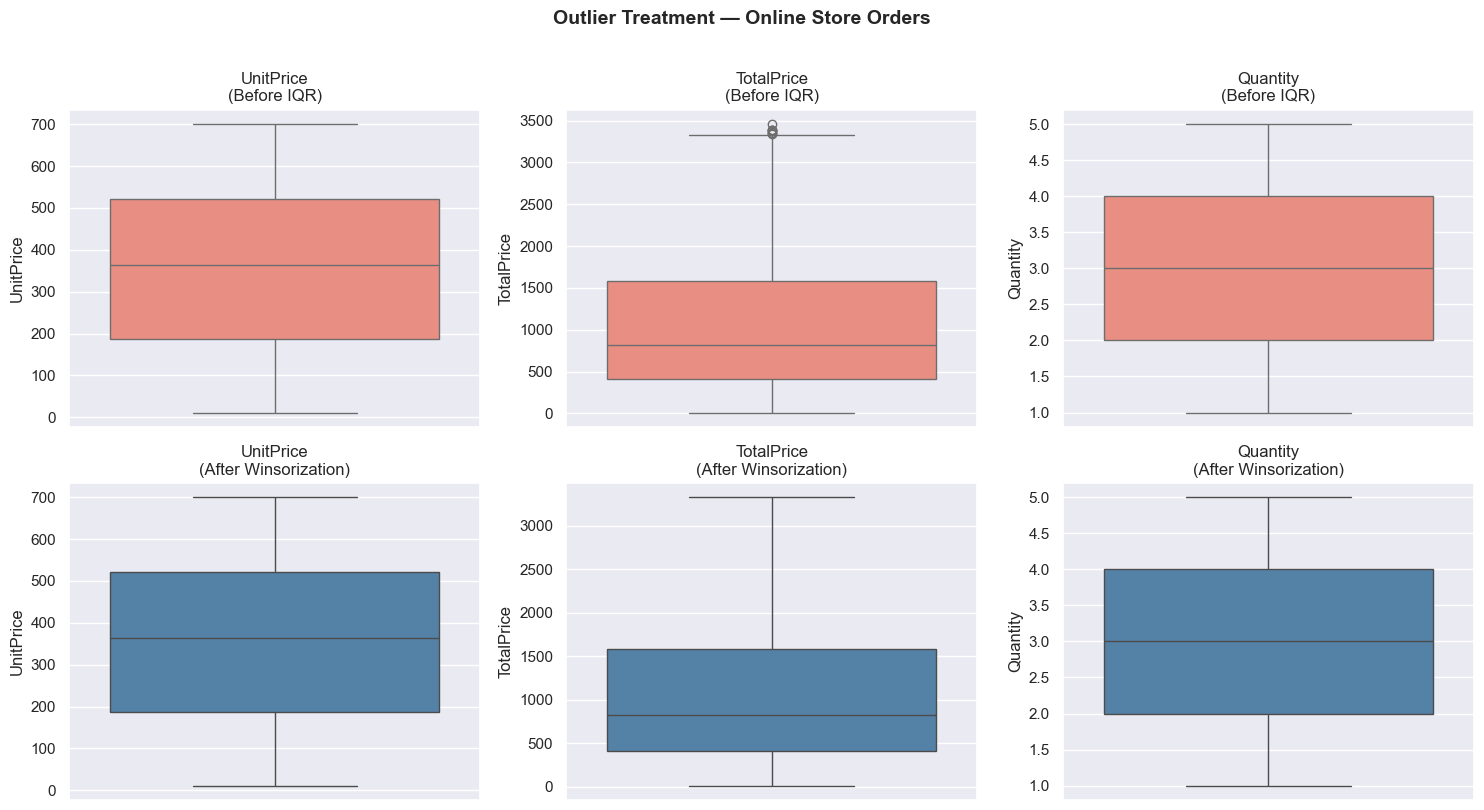

Plot saved.


In [9]:
# ── Visualize key distributions before/after for Orders ──────────────────────
key_cols = ['UnitPrice', 'TotalPrice', 'Quantity']
key_cols = [c for c in key_cols if c in orders.columns]

fig, axes = plt.subplots(2, len(key_cols), figsize=(5 * len(key_cols), 8))
for i, col in enumerate(key_cols):
    sns.boxplot(y=orders[col].dropna(), ax=axes[0, i], color='salmon')
    axes[0, i].set_title(f'{col}\n(Before IQR)')

    sns.boxplot(y=orders_clean[col], ax=axes[1, i], color='steelblue')
    axes[1, i].set_title(f'{col}\n(After Winsorization)')

plt.suptitle('Outlier Treatment — Online Store Orders', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'outlier_treatment_orders.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

---
## MODULE 2 — PROCESS: Vectorized Computation Engine
### 2.1 Feature Engineering — Engineer ≥ 3 New Predictive Features

In [10]:
# ════════════════════════════════════════════════════════════════════════════
#  ONLINE STORE ORDERS — New Features (all vectorized, zero loops)
# ════════════════════════════════════════════════════════════════════════════

df_ord = orders_clean.copy()

# Feature 1: Revenue per Item
#   Ratio of TotalPrice to Quantity — captures effective unit value
df_ord['revenue_per_item'] = df_ord['TotalPrice'] / df_ord['Quantity'].replace(0, np.nan)

# Feature 2: Has Coupon (binary flag)
#   Boolean encoded as int for estimator compatibility
df_ord['has_coupon'] = df_ord['CouponCode'].notna().astype(int)

# Feature 3: Order Month & Day-of-Week (cyclic temporal features)
df_ord['order_month']   = df_ord['Date'].dt.month
df_ord['order_dow']     = df_ord['Date'].dt.dayofweek   # 0=Monday … 6=Sunday

# Feature 4: Cart Value Density
#   TotalPrice divided by ItemsInCart — how valuable each cart slot is
df_ord['cart_value_density'] = df_ord['TotalPrice'] / df_ord['ItemsInCart'].replace(0, np.nan)

# Feature 5: Is Weekend Order
df_ord['is_weekend'] = (df_ord['order_dow'] >= 5).astype(int)

# Feature 6: Order Status Encoded (Ordinal — reflects pipeline stage)
status_order = {'Pending': 0, 'Shipped': 1, 'Delivered': 2, 'Returned': 3, 'Cancelled': 4}
df_ord['status_code'] = df_ord['OrderStatus'].map(status_order)

new_features_ord = ['revenue_per_item', 'has_coupon', 'order_month', 'order_dow',
                    'cart_value_density', 'is_weekend', 'status_code']

print('Online Store Orders — New Features:')
display(df_ord[new_features_ord].head())
print(f'   Shape: {df_ord.shape}')

Online Store Orders — New Features:


,revenue_per_item,has_coupon,order_month,order_dow,cart_value_density,is_weekend,status_code
0,570.6200,1,1,2,407.5857,0,1
1,151.3500,1,8,4,100.9000,0,1
2,550.6800,1,2,1,344.1750,0,4
3,273.1900,1,10,6,54.6380,1,3
4,626.0100,1,5,3,313.0050,0,2


   Shape: (1200, 21)


In [11]:
# ════════════════════════════════════════════════════════════════════════════
#  PRODUCT SALES REGION — New Features
# ════════════════════════════════════════════════════════════════════════════

df_sal = sales_clean.copy()

# Feature 1: Gross Profit (Revenue after Discount)
df_sal['gross_revenue']   = df_sal['Quantity'] * df_sal['UnitPrice']
df_sal['discount_amount'] = df_sal['gross_revenue'] * df_sal['Discount']
df_sal['net_revenue']     = df_sal['gross_revenue'] - df_sal['discount_amount']

# Feature 2: Delivery Lead Time (days)
df_sal['lead_time_days'] = (df_sal['DeliveryDate'] - df_sal['OrderDate']).dt.days

# Feature 3: Total Cost (Net Revenue + Shipping)
df_sal['total_cost'] = df_sal['net_revenue'] + df_sal['ShippingCost']

# Feature 4: Profit Margin Ratio
df_sal['margin_ratio'] = (df_sal['net_revenue'] - df_sal['ShippingCost']) / df_sal['net_revenue'].replace(0, np.nan)

# Feature 5: Is Returned (already 0/1) — keep; add log-transform of net_revenue
df_sal['log_net_revenue'] = np.log1p(df_sal['net_revenue'].clip(lower=0))

# Feature 6: Season (from OrderDate month)
df_sal['order_month'] = df_sal['OrderDate'].dt.month
def month_to_season(m):
    if m in [12, 1, 2]: return 'Winter'
    if m in [3, 4, 5]:  return 'Spring'
    if m in [6, 7, 8]:  return 'Summer'
    return 'Autumn'
df_sal['season'] = df_sal['order_month'].apply(month_to_season)

new_features_sal = ['gross_revenue', 'net_revenue', 'lead_time_days',
                    'total_cost', 'margin_ratio', 'log_net_revenue', 'season']

print('Product Sales Region — New Features:')
display(df_sal[new_features_sal].head())
print(f'   Shape: {df_sal.shape}')

Product Sales Region — New Features:


,gross_revenue,net_revenue,lead_time_days,total_cost,margin_ratio,log_net_revenue,season
0,2290.4000,2290.4000,4,2333.7400,0.9811,7.7369,Winter
1,544.0100,544.0100,9,549.3100,0.9903,6.3008,Winter
2,4846.5200,4361.8680,9,4382.3280,0.9953,8.3809,Spring
3,6926.7600,5887.7460,4,5915.6960,0.9953,8.6808,Winter
4,4279.6800,4279.6800,3,4285.4100,0.9987,8.3619,Summer


   Shape: (1500, 28)


### 2.2 Categorical Encoding — One-Hot Encoding (OHE)
> Label Encoding introduces false spatial hierarchy. OHE maps C classes → C orthogonal coordinate axes.

In [12]:
# ── Orders: Encode PaymentMethod, ReferralSource ──────────────────────────────
cat_cols_ord = ['PaymentMethod', 'ReferralSource']
df_ord_encoded = pd.get_dummies(df_ord, columns=cat_cols_ord, drop_first=True, dtype=int)

print(f'Orders shape before OHE : {df_ord.shape}')
print(f'Orders shape after  OHE : {df_ord_encoded.shape}')

ohe_cols = [c for c in df_ord_encoded.columns if any(cat in c for cat in cat_cols_ord)]
print(f'New OHE columns: {ohe_cols}')

Orders shape before OHE : (1200, 21)
Orders shape after  OHE : (1200, 27)
New OHE columns: ['PaymentMethod_Credit Card', 'PaymentMethod_Debit Card', 'PaymentMethod_Gift Card', 'PaymentMethod_Online', 'ReferralSource_Facebook', 'ReferralSource_Google', 'ReferralSource_Instagram', 'ReferralSource_Referral']


In [13]:
# ── Sales: Encode Region, CustomerType, Season ──────────────────────────────
cat_cols_sal = ['Region', 'CustomerType', 'season']
df_sal_encoded = pd.get_dummies(df_sal, columns=cat_cols_sal, drop_first=True, dtype=int)

print(f'Sales shape before OHE : {df_sal.shape}')
print(f'Sales shape after  OHE : {df_sal_encoded.shape}')

Sales shape before OHE : (1500, 28)
Sales shape after  OHE : (1500, 33)


### 2.3 Collinearity Eradication Algorithm
**Steps:** Build absolute correlation matrix → Isolate upper triangle → Identify pairs > 0.80 → Drop weaker vs target

In [14]:
def collinearity_eradication(df, target_col=None, threshold=0.80, label='dataset'):
    """
    Identify and remove multicollinear features.
    Keeps the feature with higher correlation to target (if provided).
    Returns: cleaned df + list of dropped columns.
    """
    numeric_df = df.select_dtypes(include=np.number).copy()

    # Step 1: Absolute correlation matrix
    corr_matrix = numeric_df.corr().abs()

    # Step 2: Upper triangle mask
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Step 3: Identify pairs > threshold
    collinear_pairs = [
        (col, row, upper.loc[row, col])
        for col in upper.columns
        for row in upper.index
        if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > threshold
    ]

    if not collinear_pairs:
        print(f'{label}: No collinear pairs found at threshold={threshold}.')
        return df, []

    print(f'\n=== Collinear Pairs > {threshold} — {label} ===')
    to_drop = set()

    for col_a, col_b, corr_val in collinear_pairs:
        if target_col and target_col in numeric_df.columns:
            # Step 4: Keep the one with higher correlation to target
            corr_a = abs(numeric_df[col_a].corr(numeric_df[target_col]))
            corr_b = abs(numeric_df[col_b].corr(numeric_df[target_col]))
            drop = col_a if corr_a < corr_b else col_b
            keep = col_b if drop == col_a else col_a
        else:
            drop = col_a  # default: drop first of pair
            keep = col_b

        to_drop.add(drop)
        print(f'  r({col_a}, {col_b}) = {corr_val:.4f} → DROP "{drop}" | KEEP "{keep}"')

    df_out = df.drop(columns=list(to_drop), errors='ignore')
    print(f'\n  Dropped {len(to_drop)} columns: {list(to_drop)}')
    print(f'  Shape: {df.shape} → {df_out.shape}')
    return df_out, list(to_drop)


# Run collinearity eradication
df_ord_final, dropped_ord = collinearity_eradication(
    df_ord_encoded, target_col='TotalPrice', threshold=0.80, label='Orders'
)
df_sal_final, dropped_sal = collinearity_eradication(
    df_sal_encoded, target_col='TotalPrice', threshold=0.80, label='Sales'
)


=== Collinear Pairs > 0.8 — Orders ===
  r(revenue_per_item, UnitPrice) = 1.0000 → DROP "revenue_per_item" | KEEP "UnitPrice"

  Dropped 1 columns: ['revenue_per_item']
  Shape: (1200, 27) → (1200, 26)

=== Collinear Pairs > 0.8 — Sales ===
  r(gross_revenue, TotalPrice) = 0.9959 → DROP "gross_revenue" | KEEP "TotalPrice"
  r(net_revenue, TotalPrice) = 0.9996 → DROP "net_revenue" | KEEP "TotalPrice"
  r(net_revenue, gross_revenue) = 0.9958 → DROP "gross_revenue" | KEEP "net_revenue"
  r(total_cost, TotalPrice) = 0.9996 → DROP "total_cost" | KEEP "TotalPrice"
  r(total_cost, gross_revenue) = 0.9957 → DROP "gross_revenue" | KEEP "total_cost"
  r(total_cost, net_revenue) = 1.0000 → DROP "total_cost" | KEEP "net_revenue"
  r(log_net_revenue, TotalPrice) = 0.8584 → DROP "log_net_revenue" | KEEP "TotalPrice"
  r(log_net_revenue, gross_revenue) = 0.8559 → DROP "log_net_revenue" | KEEP "gross_revenue"
  r(log_net_revenue, net_revenue) = 0.8559 → DROP "log_net_revenue" | KEEP "net_revenue"
  r

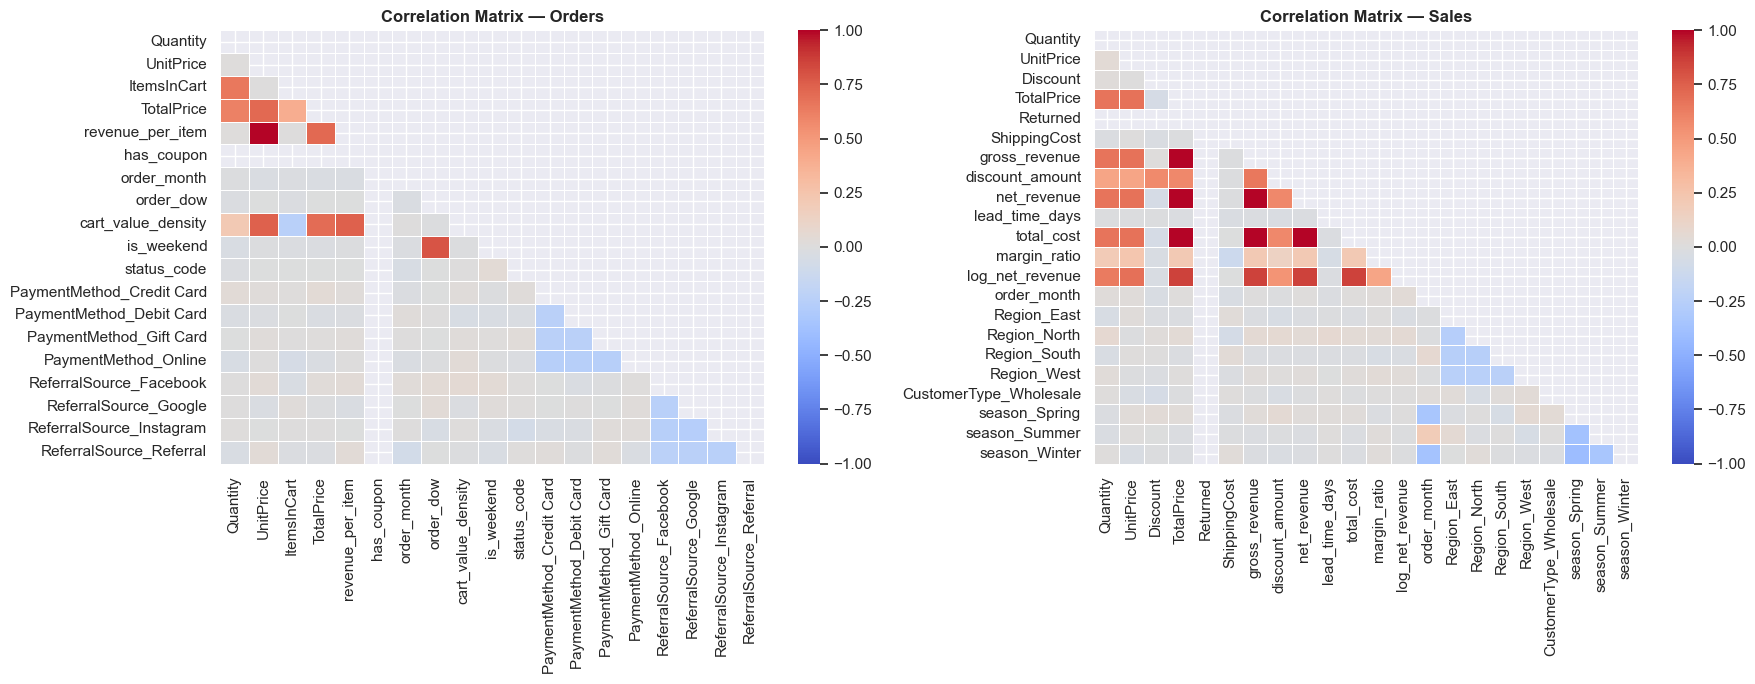

Plot saved.


In [15]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, df_, title in [
    (axes[0], df_ord_encoded.select_dtypes(include=np.number), 'Orders'),
    (axes[1], df_sal_encoded.select_dtypes(include=np.number), 'Sales')
]:
    corr = df_.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', center=0,
                linewidths=0.5, annot=len(corr) <= 12, fmt='.2f', vmin=-1, vmax=1)
    ax.set_title(f'Correlation Matrix — {title}', fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'correlation_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

### 2.4 Exploratory Data Analysis — Distributions & Key Insights

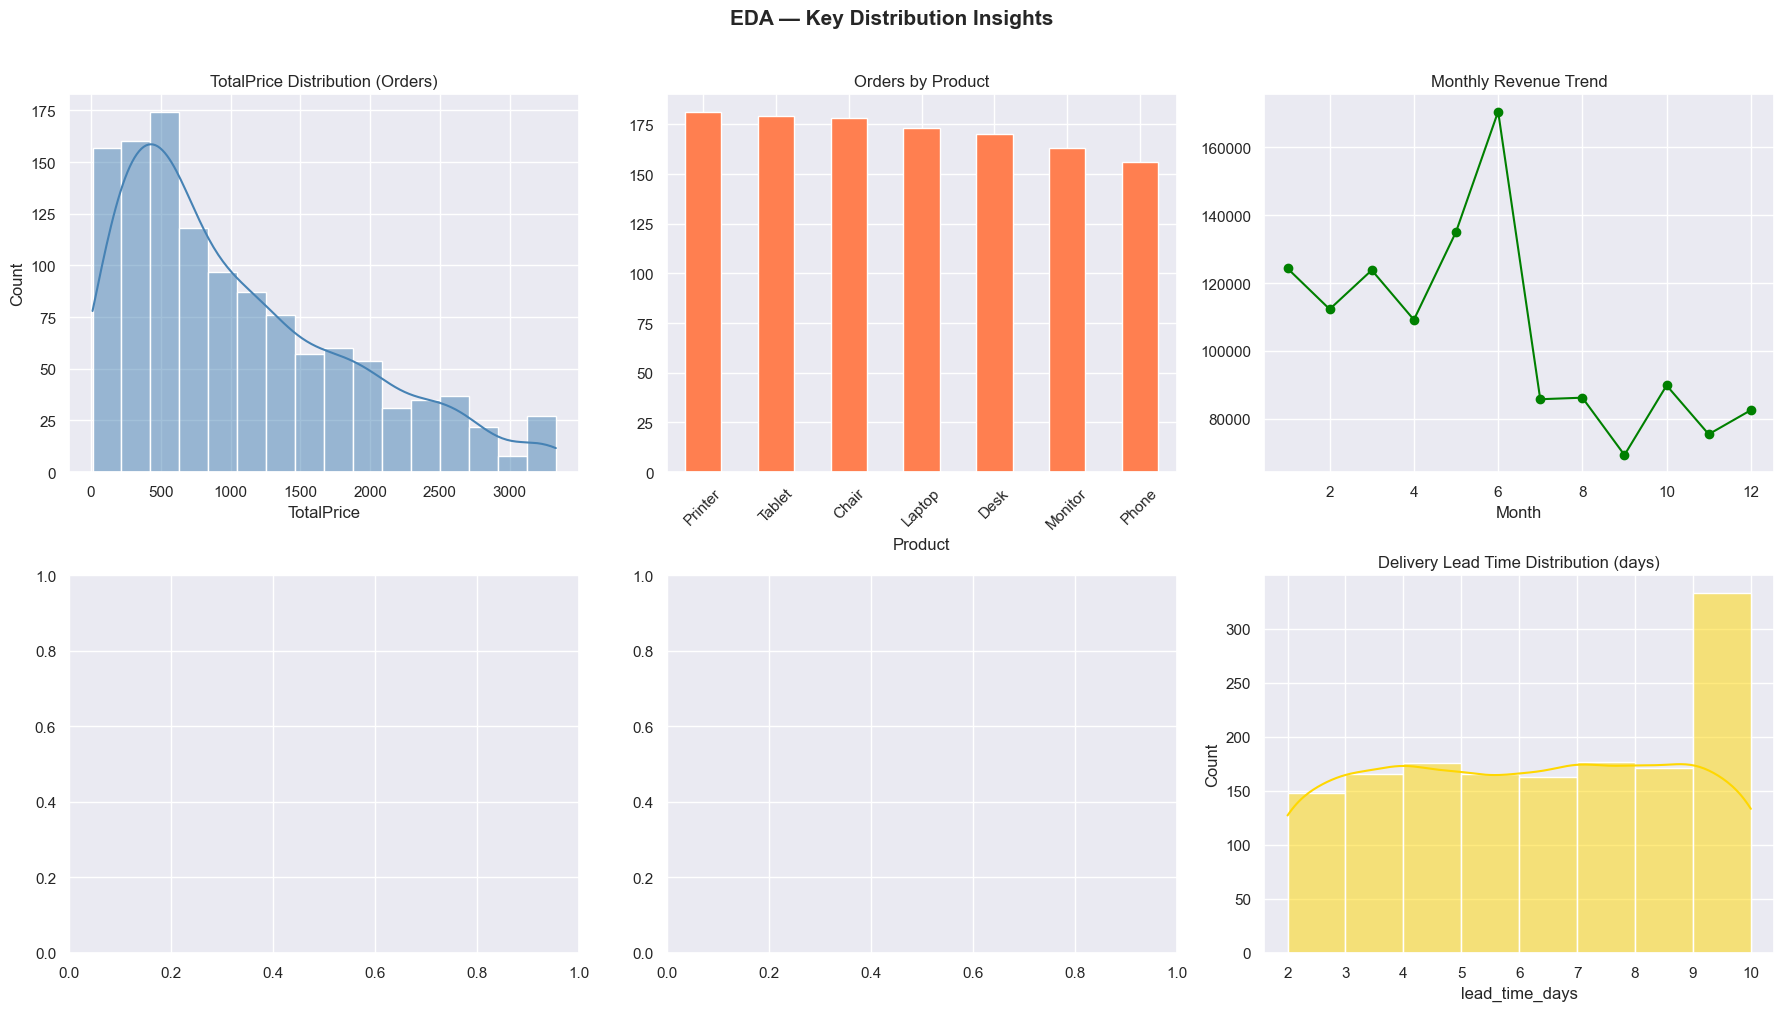

Plot saved.


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: TotalPrice distribution — Orders
sns.histplot(df_ord_final['TotalPrice'], ax=axes[0,0], kde=True, color='steelblue')
axes[0,0].set_title('TotalPrice Distribution (Orders)')

# Plot 2: Product category counts — Orders
if 'Product' in df_ord_final.columns:
    df_ord_final['Product'].value_counts().plot(kind='bar', ax=axes[0,1], color='coral')
    axes[0,1].set_title('Orders by Product')
    axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Monthly order trend
if 'order_month' in df_ord_final.columns:
    df_ord_final.groupby('order_month')['TotalPrice'].sum().plot(
        kind='line', ax=axes[0,2], marker='o', color='green')
    axes[0,2].set_title('Monthly Revenue Trend')
    axes[0,2].set_xlabel('Month')

# Plot 4: Net Revenue by Region — Sales
if 'net_revenue' in df_sal_final.columns and 'Region' in df_sal.columns:
    df_sal.groupby('Region')['TotalPrice'].sum().plot(kind='bar', ax=axes[1,0], color='mediumpurple')
    axes[1,0].set_title('Total Revenue by Region (Sales)')
    axes[1,0].tick_params(axis='x', rotation=45)

# Plot 5: Discount vs Net Revenue scatter
if 'Discount' in df_sal_final.columns and 'net_revenue' in df_sal_final.columns:
    axes[1,1].scatter(df_sal_final['Discount'], df_sal_final['net_revenue'],
                      alpha=0.5, color='teal', edgecolors='k', linewidths=0.2)
    axes[1,1].set_title('Discount vs Net Revenue')
    axes[1,1].set_xlabel('Discount Rate')
    axes[1,1].set_ylabel('Net Revenue')

# Plot 6: Lead time distribution — Sales
if 'lead_time_days' in df_sal_final.columns:
    sns.histplot(df_sal_final['lead_time_days'].dropna(), ax=axes[1,2],
                 kde=True, color='gold', binwidth=1)
    axes[1,2].set_title('Delivery Lead Time Distribution (days)')

plt.suptitle('EDA — Key Distribution Insights', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

---
## MODULE 3 — OUTPUT: Structural Contracts & Serving
### 3.1 Runtime Schema Validation with Pandera

In [17]:
if PANDERA_AVAILABLE:
    # Define the contract for the cleaned Orders dataset
    orders_schema = pa.DataFrameSchema(
        columns={
            'Quantity'          : Column(float, Check.greater_than(0)),
            'UnitPrice'         : Column(float, Check.greater_than(0)),
            'TotalPrice'        : Column(float, Check.greater_than_or_equal_to(0)),
            'has_coupon'        : Column(int,   Check.isin([0, 1])),
            'is_weekend'        : Column(int,   Check.isin([0, 1])),
            'revenue_per_item'  : Column(float, nullable=True),
        },
        coerce=True
    )

    try:
        validated = orders_schema.validate(df_ord_final, lazy=True)
        print('Pandera schema validation PASSED for Orders dataset.')
    except pa.errors.SchemaErrors as e:
        print('Schema violations detected:')
        print(e.failure_cases)
else:
    print('Pandera not available — skipping runtime validation.')
    print('   Install via: pip install pandera')

Schema violations detected:
  column      failure_case index   schema_context                check  \
0   None  revenue_per_item  None  DataFrameSchema  column_in_dataframe   

  check_number  
0         None  


### 3.2 Save Processed Datasets

In [18]:
# Save cleaned & feature-engineered datasets
df_ord_final.to_csv(DATA_PROC / 'orders_processed.csv', index=False)
df_sal_final.to_csv(DATA_PROC / 'sales_processed.csv', index=False)

print(f'Saved orders_processed.csv  → shape: {df_ord_final.shape}')
print(f'Saved sales_processed.csv   → shape: {df_sal_final.shape}')

Saved orders_processed.csv  → shape: (1200, 26)
Saved sales_processed.csv   → shape: (1500, 29)


### 3.3 Feature Store Summary Report

In [19]:
def feature_store_report(df, name, new_features):
    """Generate a feature registry summary."""
    all_features = df.columns.tolist()
    numeric_feats = df.select_dtypes(include=np.number).columns.tolist()

    report = {
        'Dataset'              : name,
        'Total Features'       : len(all_features),
        'Numeric Features'     : len(numeric_feats),
        'Engineered Features'  : len(new_features),
        'Total Rows'           : len(df),
        'Missing Values'       : df.isna().sum().sum(),
        'Engineered List'      : new_features
    }

    for k, v in report.items():
        print(f'  {k:25s}: {v}')
    print()
    return report

print('=' * 60)
print('FEATURE STORE REPORT')
print('=' * 60)

r1 = feature_store_report(
    df_ord_final, 'Online-Store-Orders',
    ['revenue_per_item', 'has_coupon', 'order_month', 'order_dow',
     'cart_value_density', 'is_weekend', 'status_code']
)

r2 = feature_store_report(
    df_sal_final, 'Product-Sales-Region',
    ['gross_revenue', 'net_revenue', 'lead_time_days',
     'total_cost', 'margin_ratio', 'log_net_revenue', 'season']
)

# Save report
import json
with open(REPORTS_DIR / 'feature_store_report.json', 'w') as f:
    def normalize_json(value):
        if isinstance(value, (np.integer, np.floating)):
            return value.item()
        if isinstance(value, (np.ndarray, list, tuple)):
            return [normalize_json(v) for v in value]
        return value
    r1_clean = {k: normalize_json(v) for k, v in r1.items()}
    r2_clean = {k: normalize_json(v) for k, v in r2.items()}
    json.dump({'orders': r1_clean, 'sales': r2_clean}, f, indent=2)

print('Feature store report saved to outputs/reports/feature_store_report.json')

FEATURE STORE REPORT
  Dataset                  : Online-Store-Orders
  Total Features           : 26
  Numeric Features         : 18
  Engineered Features      : 7
  Total Rows               : 1200
  Missing Values           : 0
  Engineered List          : ['revenue_per_item', 'has_coupon', 'order_month', 'order_dow', 'cart_value_density', 'is_weekend', 'status_code']

  Dataset                  : Product-Sales-Region
  Total Features           : 29
  Numeric Features         : 18
  Engineered Features      : 7
  Total Rows               : 1500
  Missing Values           : 0
  Engineered List          : ['gross_revenue', 'net_revenue', 'lead_time_days', 'total_cost', 'margin_ratio', 'log_net_revenue', 'season']

Feature store report saved to outputs/reports/feature_store_report.json


---
## Summary & Pipeline Completion

| Phase | Actions Completed |
|---|---|
| **MODULE 1 — INPUT** | Loaded 2 datasets · Fixed Excel date serials · Applied Missing Data Decision Matrix (Drop/Median/KNN) · IQR Winsorization |
| **MODULE 2 — PROCESS** | Engineered 7 new features per dataset · Applied One-Hot Encoding · Ran Collinearity Eradication Algorithm (threshold=0.80) · EDA plots |
| **MODULE 3 — OUTPUT** | Pandera runtime schema validation · Exported processed CSVs · Generated Feature Store Report |

